# Oppgave 2
Lager først funksjoner for sannsynlighetene $p^-$, $p^0$ og $p^+$ og deretter en random walk simulasjon. 

In [78]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random

# Uniformt potensial
k = 1
def V(x):
    return k

# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x):
    return 1/(1+np.exp(-np.clip(beta*(V(x-h)-V(x+h)), -500, 500)) + np.exp(-np.clip(beta*(V(x)-V(x+h)), -500, 500)))

def p_null(x):
    return 1/(1+np.exp(-np.clip(beta*(V(x-h)-V(x)), -500, 500)) + np.exp(-np.clip(beta*(V(x+h)-V(x)), -500, 500)))

def p_minus(x):
    return 1/(1+np.exp(-np.clip(beta*(V(x+h)-V(x-h)), -500, 500)) + np.exp(-np.clip(beta*(V(x)-V(x-h)), -500, 500)))

beta = 1
delta_t = 1 # Tidssteg lengde
h = 1 # Steg lengde
n = 1000 # Antall partikler
t = 200 # Antall tidssteg
bin_size = int(2* np.cbrt(n))

# Funksjon for random walk simulasjon
def sim():
    arr =  np.zeros(n) # Array med alle partikklene i posisjon x=0, iterer gjennom partikler og tidssteg
    for i in range(0, t, delta_t):
        for j in range(n):
            a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
            if a <= p_minus(arr[j]):
                arr[j] -= h
            elif (1 - p_plus(arr[j])) < a:
                arr[j] += h
    return arr


# a)
Simulerer for potensial $V(x) = k$ med $\beta \in \{0.01, 1, 100\}$  
For konstant potensial er sannsynligheten for å gå til høyre, stå stille og gå til venstre lik og derfor er partiklene jevnt fordelt i rommet. Dette er illustrert i histogrammene under.


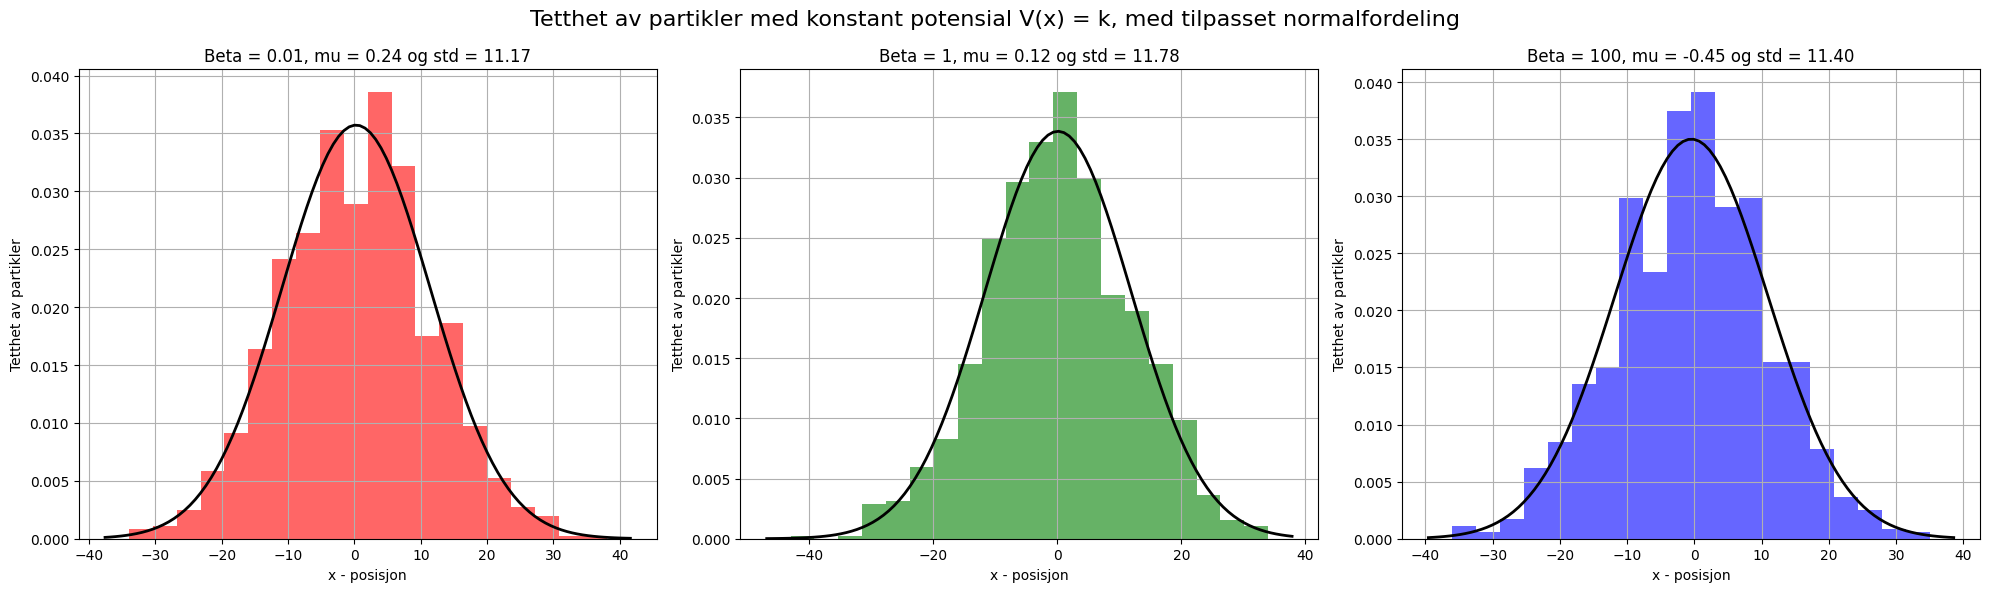

In [44]:
#Definerer konstant positivt potensial
def V(x):
    return k

#itererer gjennom beta verdier og plotter histogram og tilpasset normalfordeling
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
for i, beta, color in zip(range(3), [0.01, 1, 100], ['r', 'g', 'b']):
    particles1 = sim()
    mu, std = scipy.stats.norm.fit(particles1)
    axs[i].hist(particles1, bins=bin_size, density=True, alpha=0.6, color=color)

    xmin, xmax = axs[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = scipy.stats.norm.pdf(x, mu, std)
    axs[i].plot(x, p, 'k', linewidth=2)
    axs[i].set_xlabel("x - posisjon")
    axs[i].set_ylabel("Tetthet av partikler")
    axs[i].set_title(f"β = {beta}, μ = {mu:.2f} og σ = {std:.2f}")
    axs[i].grid()


plt.suptitle("Tetthet av partikler med konstant potensial V(x) = k, med tilpasset normalfordeling", fontsize=16)
plt.tight_layout()
plt.show()

# b)
Simulerer for potensial $V(x) = -k$ med $\beta \in \{0.01, 1, 100\}$  
Forklaringen for dette er lik som for a), siden det er konstant potensial.

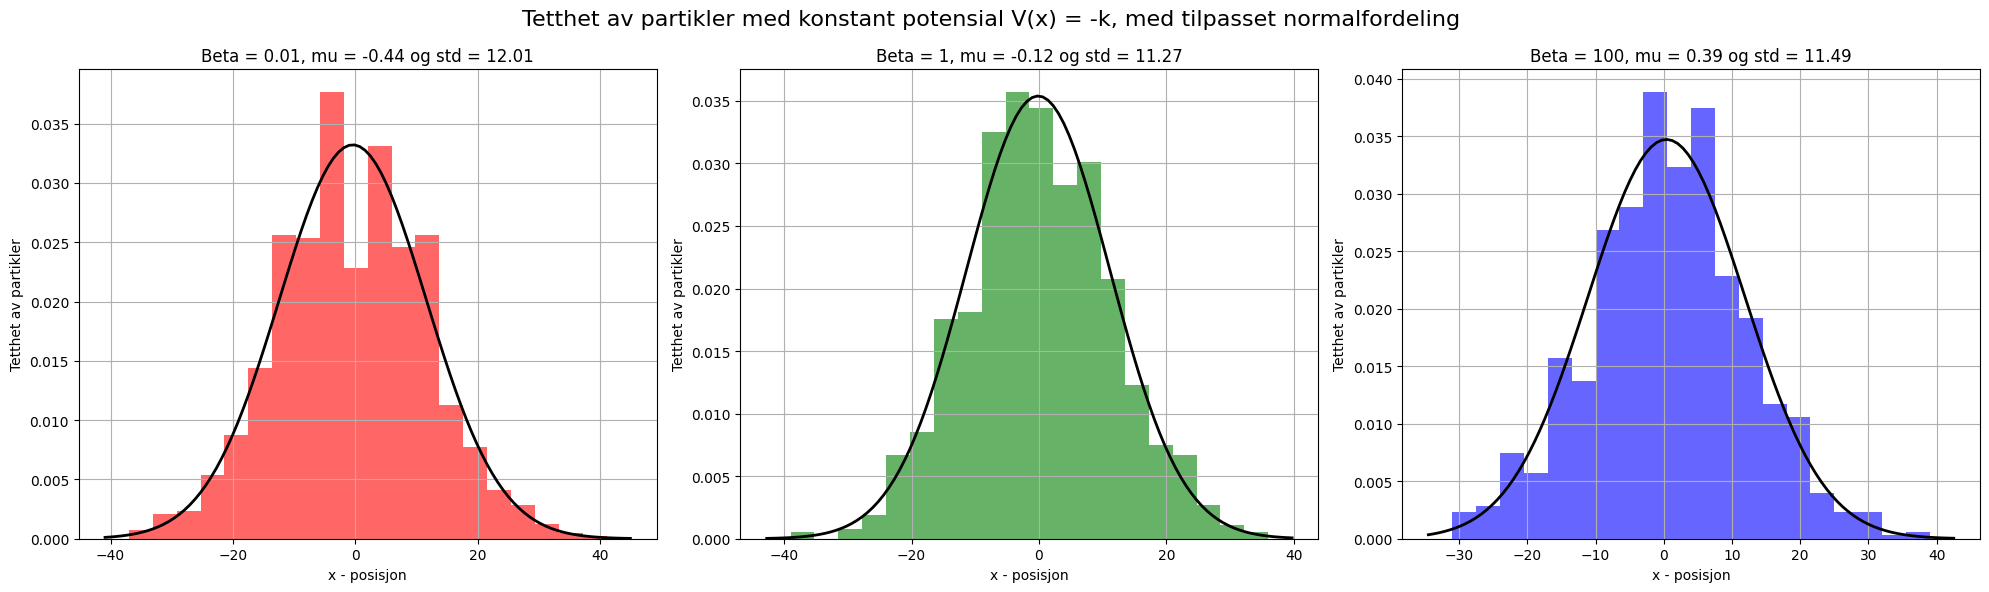

In [45]:
def V(x):
    return -k

#itererer gjennom beta verdier og plotter histogram og tilpasset normalfordeling
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
for i, beta, color in zip(range(3), [0.01, 1, 100], ['r', 'g', 'b']):
    particles2 = sim()
    mu, std = scipy.stats.norm.fit(particles2)
    axs[i].hist(particles2, bins=bin_size, density=True, alpha=0.6, color=color)

    xmin, xmax = axs[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = scipy.stats.norm.pdf(x, mu, std)
    axs[i].plot(x, p, 'k', linewidth=2)
    axs[i].set_xlabel("x - posisjon")
    axs[i].set_ylabel("Tetthet av partikler")
    axs[i].set_title(f"β = {beta}, μ = {mu:.2f} og σ = {std:.2f}")
    axs[i].grid()


fig.suptitle("Tetthet av partikler med konstant potensial V(x) = -k, med tilpasset normalfordeling ", fontsize=16)
plt.tight_layout()
plt.show()

# c)
Simulerer for potensial $V(x) = k\cdot (\frac{x}{15} - cos(\frac{x}{3}))$ med $\beta \in \{0.01, 1, 100\}$

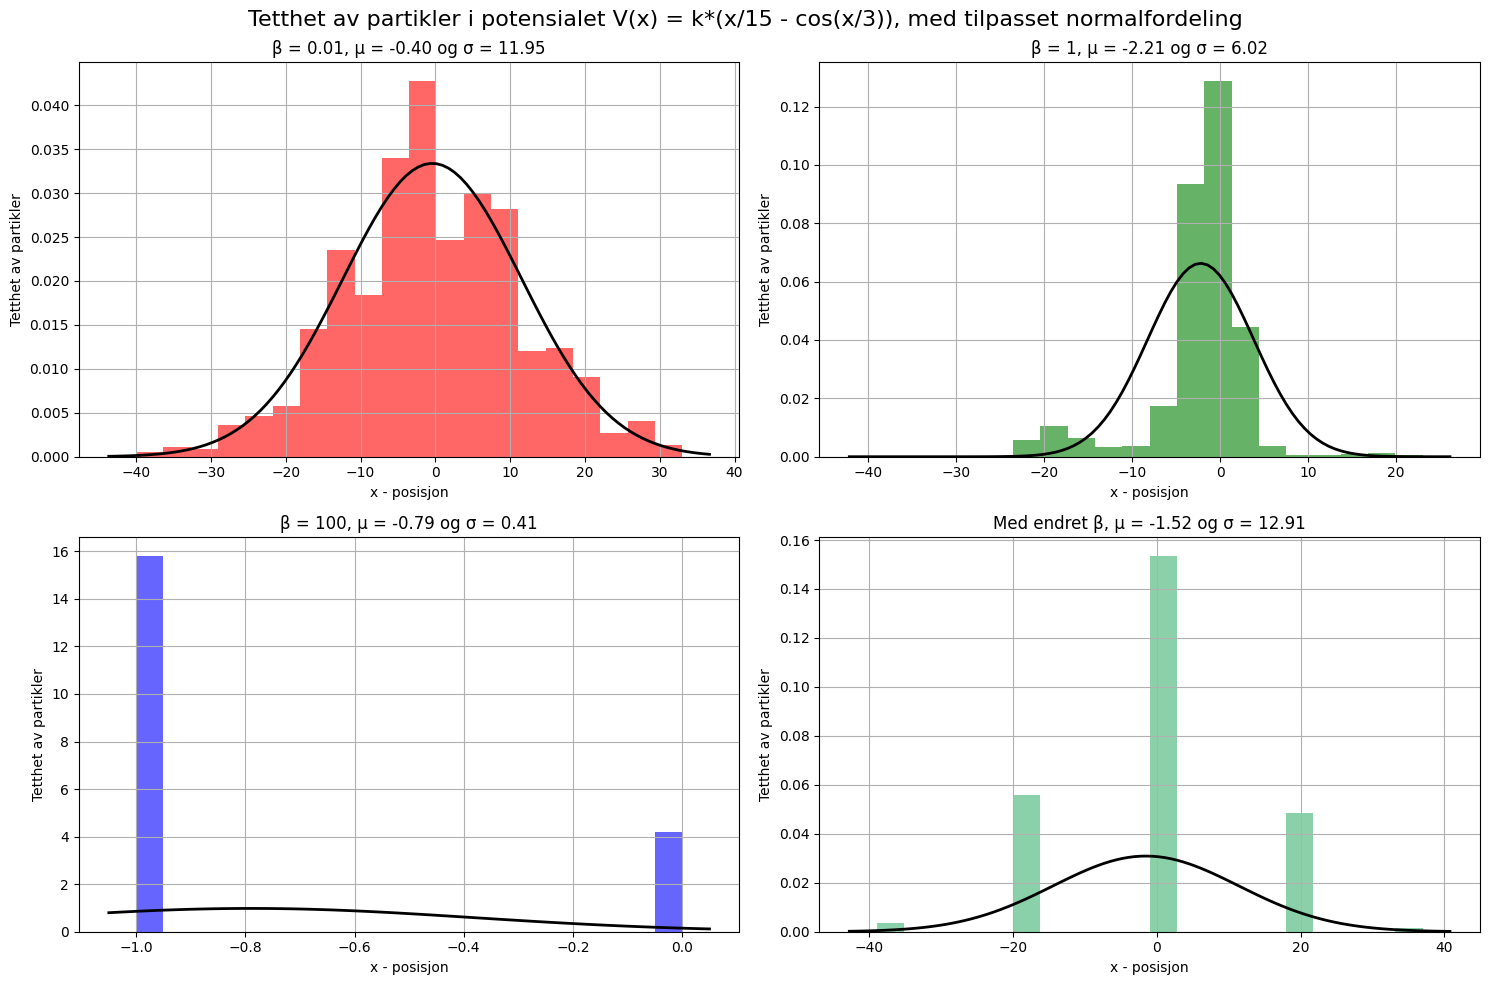

In [79]:
def V(x):
    return k*(x/15 - np.cos(x/3))



fig, ax = plt.subplots(2, 2, figsize=(15, 10))
for i, (beta, color) in enumerate(zip([0.01, 1, 100], ['r', 'g', 'b'])):
    particles3 = sim()
    mu, std = scipy.stats.norm.fit(particles3)
    row, col = divmod(i, 2)
    ax[row, col].hist(particles3, bins=bin_size, density=True, alpha=0.6, color=color)

    xmin, xmax = ax[row, col].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = scipy.stats.norm.pdf(x, mu, std)
    ax[row, col].plot(x, p, 'k', linewidth=2)
    ax[row, col].set_xlabel("x - posisjon")
    ax[row, col].set_ylabel("Tetthet av partikler")
    ax[row, col].set_title(f"β = {beta}, μ = {mu:.2f} og σ = {std:.2f}")
    ax[row, col].grid()

# Ekstraoppgave
arr = np.zeros(n)
beta = 0.01
for i in range(0, 2 * t, delta_t):  # Dobbel tidssteg lengde
    if i > t:  # Endrer beta verdi etter halve tidssteg
        beta = 100
    for j in range(n):
        a = random.uniform(0, 1)
        if a < p_minus(arr[j]):
            arr[j] -= h
        elif (1 - p_plus(arr[j])) < a:
            arr[j] += h
ax[1, 1].hist(arr, bins=bin_size, density=True, alpha=0.6, color='mediumseagreen')  # Tilpasser normalfordeling
mu, std = scipy.stats.norm.fit(arr)
xmin, xmax = ax[1, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = scipy.stats.norm.pdf(x, mu, std)
ax[1, 1].plot(x, p, 'k', linewidth=2)
ax[1, 1].set_xlabel("x - posisjon")
ax[1, 1].set_ylabel("Tetthet av partikler")
ax[1, 1].set_title(f"Med endret β, μ = {mu:.2f} og σ = {std:.2f}")
ax[1, 1].grid()

fig.suptitle("Tetthet av partikler i potensialet V(x) = k*(x/15 - cos(x/3)), med tilpasset normalfordeling", fontsize=16)
plt.tight_layout()
plt.show()


Forklaring:  
1) Når $\beta = 0.01$, spiller ikke potensialet noe rolle og simulasjonen går mot en normal fordeling.

2) Når $\beta = 1$, spiller potensialet en større rolle og mesteparten vil holde seg innenfor den gropen mellom $-5$ og $5$, men noen vil migrere over høypotensial området for å komme til gropen mellom $-25$ og $-15$ og veldig lite til gropen mellom $15$ og $25$.

3) Når $\beta = 100$ vil partiklene holde seg i de laveste potensialene $(V(-1) = -1.01$ og $V(0) = -1)$, mens ingen vil bevege seg til $x = 1$ hvor $V(x) = -0.88$

4) Når $\beta = 0.01$ vil partiklene spre seg jevnt utover, slik som i første plott i 2c, mens når $\beta = 100$ vil partiklene holde seg i de laveste potensialene rundt der de oppholder seg etter den første fordelingen. Da vil de samle seg mest ved de lokale minimumene til potensialet, som er ved $x = -19.45, x = -0.6$ og $x = 18.25$


# d)
Simulerer for potensial $V(x) = k\cdot x^4$ med $\beta \in \{0.01, 1, 100\}$

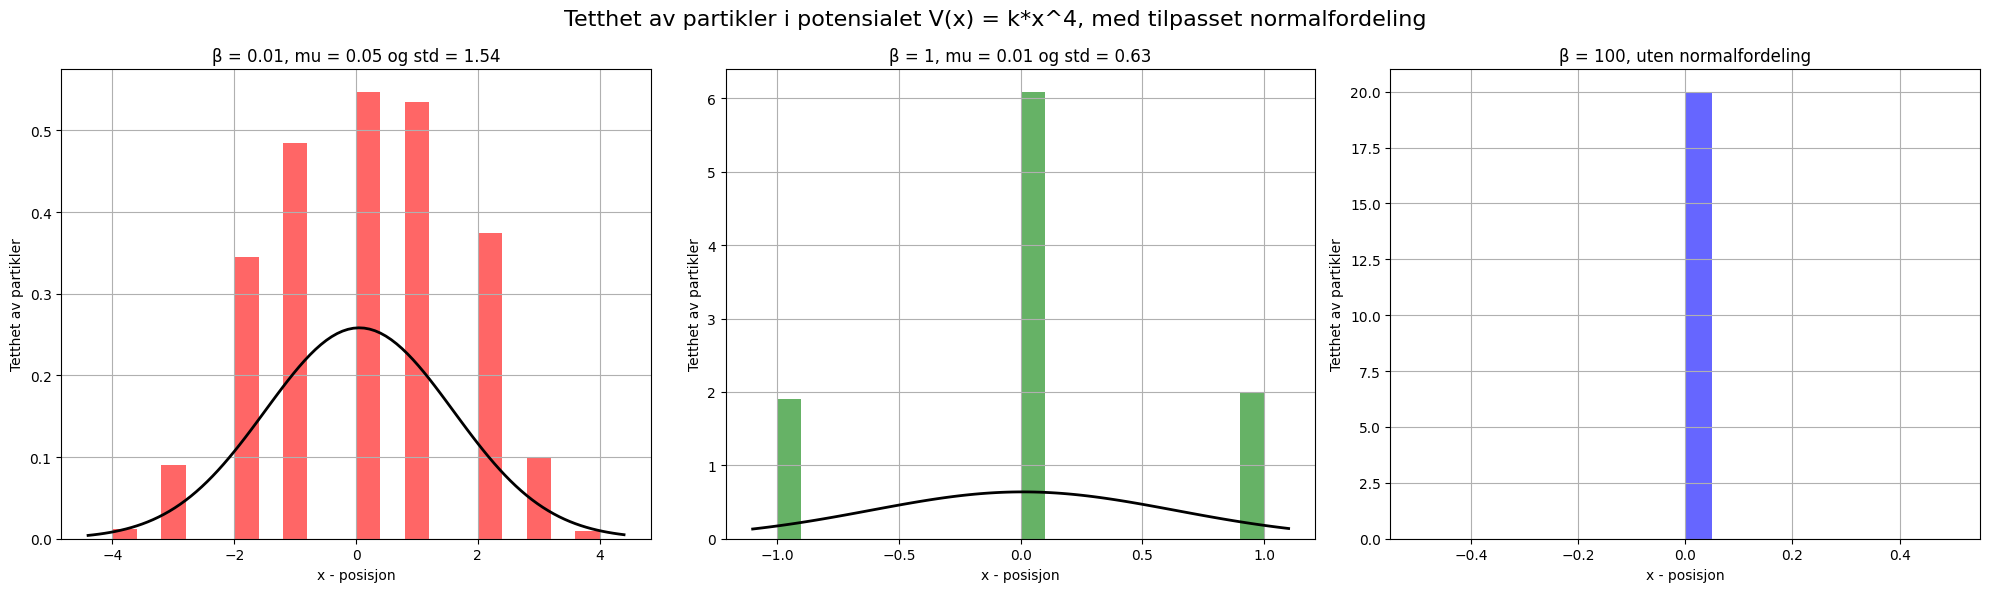

In [77]:
def V(x):
    return k*x**4

#Simulerer og plotter for beta = 0.01 og beta = 1
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
for i, beta, color in zip(range(2), [0.01, 1], ['r', 'g']):
    particles4 = sim()
    mu, std = scipy.stats.norm.fit(particles4)
    ax[i].hist(particles4, bins=bin_size, density=True, alpha=0.6, color=color)

    xmin, xmax = ax[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = scipy.stats.norm.pdf(x, mu, std)
    ax[i].plot(x, p, 'k', linewidth=2)
    ax[i].set_xlabel("x - posisjon")
    ax[i].set_ylabel("Tetthet av partikler")
    ax[i].set_title(f"β = {beta}, mu = {mu:.2f} og std = {std:.2f}")
    ax[i].grid()


#For beta = 100 blir normalfordelingen en dirac delta funksjon
beta = 100
particles4 = sim()
mu, std = scipy.stats.norm.fit(particles4)
xmin, xmax = ax[2].get_xlim()
ax[2].hist(particles4, bins=bin_size, density=True, alpha=0.6, color='b')
ax[2].set_xlabel("x - posisjon")
ax[2].set_ylabel("Tetthet av partikler")
ax[2].set_title(f"β = {beta}, uten normalfordeling")
ax[2].grid()

fig.suptitle("Tetthet av partikler i potensialet V(x) = k*x^4, med tilpasset normalfordeling", fontsize=16)
plt.tight_layout()
plt.show()


Forklaring:  
I dette potensialet er minimumet ved $x = 0$ og det vokser eksponensielt med avstanden fra origo. Dette gjør at når $\beta = 0.01$ vil fortsatt potensialet hindre partiklene fra å bevege seg for langt unna origo. Siden ved $x = \pm 4$ er $V(x) = 16\cdot k$ som gjør at $p^{\mp} = 0.00368$.  
Når $\beta = 1$ er potensialet allerede såpass dominerende at ingen partikler kommer seg lengre enn 1 lengde unna origo.  
Med $\beta = 100$ er det for stor potensial forskjell mellom $x = 0$ og $x = \pm 1$ at ingen partikler beveger seg.

Dette viser at når potensialet vokser så fort som her kan man ikke bruke $\beta k$ for å bestemme om den termisk energien eller potensialet dominerer. Hvis man setter $\beta = 10^{-5}$ vil den termiske energien nok en gang dominere, men det viser at man kan ikke bare se på $\beta$.